# W Loading Tests — Immucan IF (real data)

Analogicznie do `w_loading_tests.ipynb`, ale na przygotowanych danych Immucan IF.
Brak ground-truth `W` / `Z` — testy używają **stabilności między seedami** i **cohort vs baseline**.

Podzbiór próbek: **pierwsze N wierszy manifestu per kohorta** (kolejność w `IF*_file_df_MOFA.txt`),
nie losowy sampling i nie pełny zbiór.

| # | Odpowiednik SC | W_prior | Z_prior | Co testuje |
|---|----------------|---------|---------|------------|
| **IM1** | SC1 | ARD_SS | STD_NORMAL | Stabilność `W` między seedami (|corr| do seed=0) |
| **IM2** | SC2 | ARD_SS | STD_NORMAL | Rzadkość ładunków: heatmapy `E[W]`, `E[S]` |
| **IM3** | SC3 | ARD_SS | COHORT | Czynnik kohortowy + cechy o najwyższym |W| |
| **IM4** | SC4 | ARD_SS | COHORT vs STD_NORMAL | Stabilność `W`: cohort vs baseline |

Każda sekcja: **Cel** → **Dane** → **Kroki** → **Wyjścia** → **Interpretacja**.

Wymaga T7: `IMMUCAN_ROOT`.

### Importy

In [1]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath('.'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import FACTModel
from src.factor_alignment import (
    hungarian_factor_alignment as hungarian,
    w_corr_vs_reference_model as w_corr_vs_ref,
    w_stability_between_models as w_stability,
)
from src.enums import Likelihood, WPrior, ZPrior
from src.model_config import CohortPriorConfig, ModelConfig, SimpleViewConfig

from immucan_data import immucan_load_plan, immucan_model_config, load_immucan


### Helpery: fitting, Hungarian, W-stabilność (jak w w_loading_tests)

In [2]:
def fit_ard_ss(views, K, max_iter=150, seed=0, n_topics=10):
    cfg = immucan_model_config(
        views, K, z_prior=ZPrior.STD_NORMAL, n_topics=n_topics
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def fit_cohort(views, K, pi=0.5, max_iter=150, seed=0, n_topics=10):
    cfg = immucan_model_config(
        views, K, z_prior=ZPrior.COHORT, pi=pi, n_topics=n_topics
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def fit_baseline(views, K, max_iter=150, seed=0):
    return fit_ard_ss(views, K, max_iter=max_iter, seed=seed)


# hungarian, w_corr_vs_ref, w_stability — imported from src.factor_alignment


---
## IM0 — Ładowanie danych (pierwsze przypadki z manifestu)

**Cel:** Załadować mały, deterministyczny podzbiór Immucan IF.

### Dane (given)
- `FIRST_N_PER_COHORT = 8` — pierwsze 8 próbek per kohorta w kolejności manifestu (~40 próbek × 5 kohort)
- Panel `IF1`, z-score per widok

### Wyjścia
- Plan ładowania + wymiary `Views`

In [3]:
IMMUCAN_ROOT = "/Volumes/T7/immucan/results/IF/05_IF_table_extraction"
FIRST_N_PER_COHORT = 8
IMMUCAN_PANELS = ("IF1",)
REBUILD_CACHE = False

K = 6
MAX_ITER = 150
PI = 0.5

print(immucan_load_plan(
    IMMUCAN_ROOT,
    panels=IMMUCAN_PANELS,
    first_n_per_cohort=FIRST_N_PER_COHORT,
))

data = load_immucan(
    IMMUCAN_ROOT,
    panels=IMMUCAN_PANELS,
    first_n_per_cohort=FIRST_N_PER_COHORT,
    max_samples_per_cohort=None,
    rebuild_cache=REBUILD_CACHE,
    standardize=True,
    progress=True,
)
views = data.views
cohort_labels = data.cohorts
FEATURE_NAMES = sorted(data.long_df['feature'].unique())
print(
    f"N={views.N}, D={views.simple[0].D}, structured={views.num_structured}, "
    f"G={views.structured[0].G if views.num_structured else 0}, "
    f"topics={data.n_topics}, cohorts={pd.Series(cohort_labels).value_counts().to_dict()}"
)


{'panels': ['IF1'], 'n_tsv_files_to_read': 40, 'per_panel': {'IF1': {'n_samples': 40, 'cohorts': {'IMMU_BC1': 8, 'IMMU_NSCLC': 8, 'IMMU_RCC': 8, 'IMMU_SCCHN1': 8, 'SYNG_BC1': 8}}}, 'structured_views': 'one CTM view per panel (spatial kNN windows from tables/)', 'default_topics': 10, 'default_window_size': 75, 'note': 'Manifest paths only; does not scan tables/ beyond listed TSVs.'}
Immucan: loading cache data/immucan_IF1_cc39202ad7bb.csv


structured panels: 100%|██████████| 1/1 [00:41<00:00, 41.52s/it]

Immucan: structured cache saved to data/immucan_structured_IF1_8b179c73cd62.pkl
N=27, D=17, structured=1, G=9, topics=10, cohorts={'BC1': 6, 'SCCHN1': 6, 'SYG_BC1': 6, 'NSCLC': 5, 'RCC': 4}


---
## IM1 — Stabilność ładunków W między seedami (odpowiednik SC1)

**Cel:** Przy tych samych danych różne inicjalizacje powinny dać podobne `W` po Hungarian (jak SC1 bez znanej macierzy — mierzymy reprodukowalność).

### Kroki
1. `fit_ard_ss` dla `seeds = [0,1,2,3,4]`
2. `|corr(W_seed, W_seed0)|` per czynnik, uśrednienie
3. Wykres errorbar + heatmapa `W` dla seed=0

### Oczekiwane
- Mean |corr| > 0.7 przy stabilnym N i z-score

Pretraining CTM for structured view 0
Pretraining FA
Fitting model


100%|██████████| 150/150 [00:20<00:00,  7.43it/s]


Pretraining CTM for structured view 0
Pretraining FA
Fitting model


100%|██████████| 150/150 [00:20<00:00,  7.45it/s]


Pretraining CTM for structured view 0
Pretraining FA
Fitting model


...

Pretraining CTM for structured view 0
Pretraining FA
Fitting model


100%|██████████| 150/150 [00:20<00:00,  7.35it/s]


Pretraining CTM for structured view 0
Pretraining FA
Fitting model


100%|██████████| 150/150 [00:21<00:00,  7.03it/s]


seed 1 vs 0: mean|corr|=0.492
seed 2 vs 0: mean|corr|=0.467
seed 3 vs 0: mean|corr|=0.463
seed 4 vs 0: mean|corr|=0.437
Mean across seeds: 0.465 ± 0.019


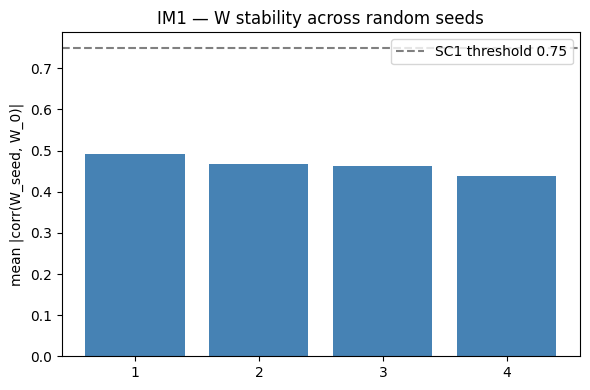

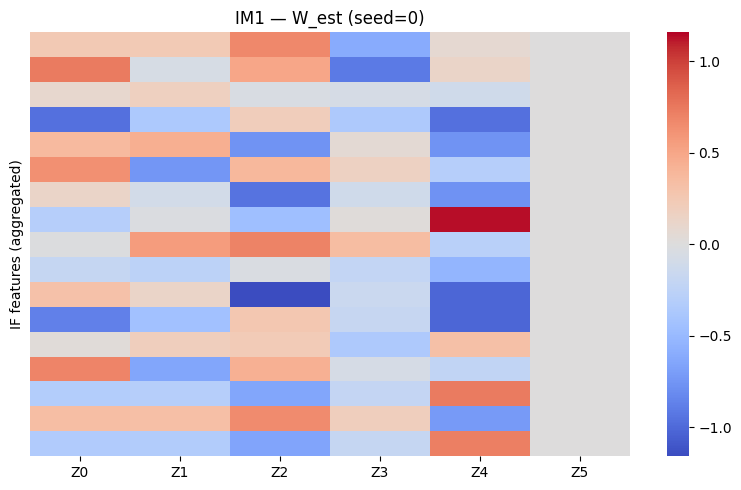

In [4]:
seeds_im1 = [0, 1, 2, 3, 4]
models_im1 = {}
for seed in seeds_im1:
    models_im1[seed] = fit_ard_ss(views, K, max_iter=MAX_ITER, seed=seed)

ref = models_im1[0]
results_im1 = []
for seed in seeds_im1[1:]:
    wc = w_corr_vs_ref(ref, models_im1[seed], K)
    results_im1.append(wc[0].mean())
    print(f"seed {seed} vs 0: mean|corr|={wc[0].mean():.3f}")

means_im1 = results_im1
print(f"Mean across seeds: {np.mean(means_im1):.3f} ± {np.std(means_im1):.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(len(seeds_im1[1:])), means_im1, color='steelblue')
ax.axhline(0.75, color='gray', ls='--', label='SC1 threshold 0.75')
ax.set_xticks(range(len(seeds_im1[1:])))
ax.set_xticklabels([str(s) for s in seeds_im1[1:]])
ax.set_ylabel('mean |corr(W_seed, W_0)|')
ax.set_title('IM1 — W stability across random seeds')
ax.legend()
plt.tight_layout()
plt.show()

W0 = ref.fa.nodelist_w[0].E_w
vmax = np.abs(W0).max()
plt.figure(figsize=(8, 5))
sns.heatmap(W0, cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
            xticklabels=[f'Z{k}' for k in range(K)], yticklabels=False)
plt.title('IM1 — W_est (seed=0)')
plt.ylabel('IF features (aggregated)')
plt.tight_layout()
plt.show()


---
## IM2 — Struktura rzadkości ładunków ARD_SS (odpowiednik SC2)

**Cel:** Ogląd `E[W]` i `E[S]` (spike-and-slab) na prawdziwych cechach IF — które cechy ładują które czynniki.

### Kroki
1. Jeden fit `fit_ard_ss` (seed=7)
2. Heatmapy `E[W]` i `E[S]`
3. Top-5 cech per czynnik (|W|)

Pretraining CTM for structured view 0
Pretraining FA
Fitting model


100%|██████████| 150/150 [00:20<00:00,  7.23it/s]


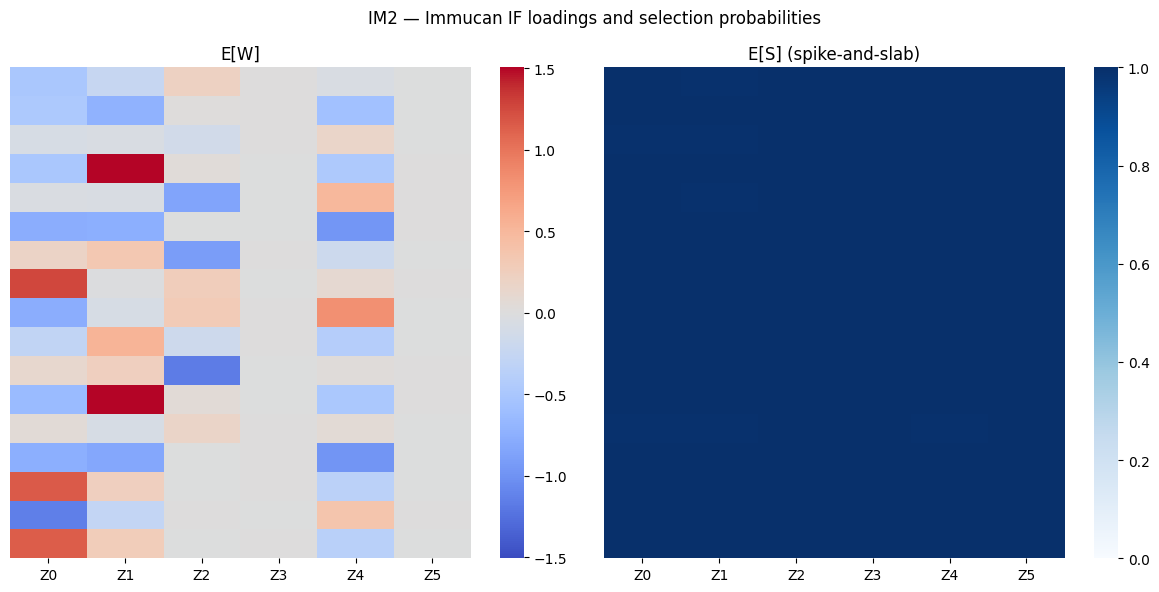

Z0 top features: ['celltype_Tumor_view0', 'marker_CK_view0', 'tissue_stroma_view0', 'tissue_tumor_view0', 'celltype_other_view0']
Z1 top features: ['celltype_MacCD163_view0', 'marker_CD163_view0', 'marker_CD3_view0', 'celltype_T_view0', 'celltype_BnT_view0']
Z2 top features: ['marker_CD15_view0', 'celltype_Tumor_CD15_view0', 'celltype_Neutrophil_view0', 'celltype_other_view0', 'celltype_Tumor_view0']
Z3 top features: ['celltype_Tumor_view0', 'marker_CK_view0', 'celltype_T_view0', 'celltype_Neutrophil_view0', 'marker_CD15_view0']
Z4 top features: ['marker_CD3_view0', 'celltype_T_view0', 'celltype_other_view0', 'celltype_BnT_view0', 'celltype_Neutrophil_view0']
Z5 top features: ['celltype_Tumor_view0', 'marker_CK_view0', 'celltype_T_view0', 'celltype_Neutrophil_view0', 'marker_CD15_view0']


In [5]:
model_im2 = fit_ard_ss(views, K, max_iter=MAX_ITER, seed=7)
W_est = model_im2.fa.nodelist_w[0].E_w
S_est = model_im2.fa.nodelist_w[0].s_m_node.vi_gamma

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
vmax = np.percentile(np.abs(W_est), 99)
sns.heatmap(W_est, ax=axes[0], cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
            xticklabels=[f'Z{k}' for k in range(K)], yticklabels=False)
axes[0].set_title('E[W]')
sns.heatmap(S_est, ax=axes[1], cmap='Blues', vmin=0, vmax=1,
            xticklabels=[f'Z{k}' for k in range(K)], yticklabels=False)
axes[1].set_title('E[S] (spike-and-slab)')
plt.suptitle('IM2 — Immucan IF loadings and selection probabilities')
plt.tight_layout()
plt.show()

for k in range(K):
    idx = np.argsort(np.abs(W_est[:, k]))[::-1][:5]
    print(f"Z{k} top features:", [FEATURE_NAMES[i] for i in idx])


---
## IM3 — Czynnik kohortowy i cechy (odpowiednik SC3)

**Cel:** Model `COHORT` powinien wskazać czynniki z wysokim `E[gamma]` per typ nowotworu; sprawdzamy top |W| na tym czynniku.

### Kroki
1. `fit_cohort`
2. Heatmapy `E[gamma]`, `E[gamma·delta]`
3. Czynnik z max różnicą `E[gamma]` między kohortami → top cechy |W|

Pretraining CTM for structured view 0
Pretraining FA
Fitting model


100%|██████████| 150/150 [00:20<00:00,  7.28it/s]


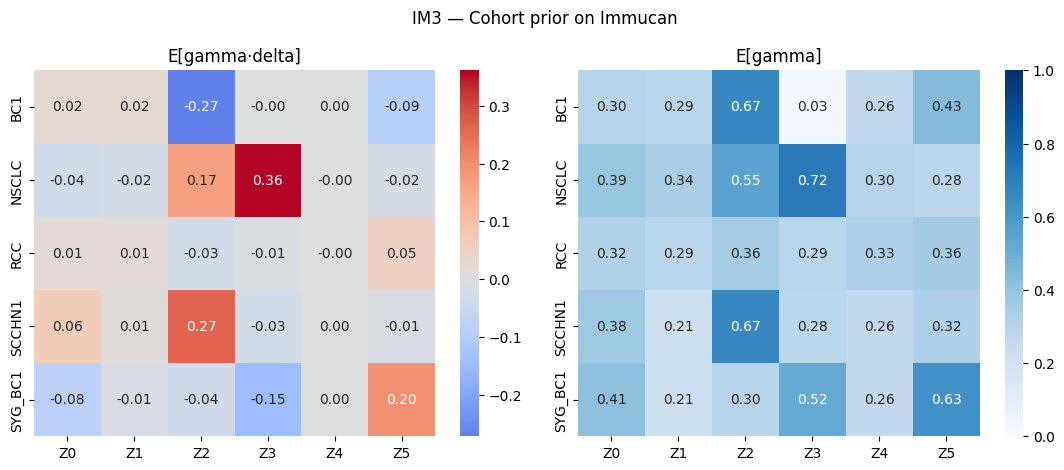

Cohort factor (max E[gamma] spread): Z3, spread=0.687
Top |W| features on cohort factor:
  marker_CD3_view0: W=1.283
  celltype_T_view0: W=1.248
  celltype_BnT_view0: W=1.001
  celltype_other_view0: W=-0.589
  celltype_Neutrophil_view0: W=-0.463
  celltype_MacCD163_view0: W=-0.276
  celltype_B_view0: W=0.261
  marker_CD15_view0: W=-0.213


In [6]:
model_im3 = fit_cohort(views, K, pi=PI, max_iter=MAX_ITER, seed=13)
priors = model_im3.fa.node_z.z_priors
E_g = np.column_stack([priors[k].E_gamma for k in range(K)])
E_d = np.column_stack([priors[k].E_delta for k in range(K)])
cohort_names = [str(c) for c in priors[0].cohort.labels]

fig, axes = plt.subplots(1, 2, figsize=(11, 0.55 * len(cohort_names) + 2))
sns.heatmap(E_g * E_d, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=[f'Z{k}' for k in range(K)], yticklabels=cohort_names, ax=axes[0])
axes[0].set_title('E[gamma·delta]')
sns.heatmap(E_g, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=[f'Z{k}' for k in range(K)], yticklabels=cohort_names, ax=axes[1])
axes[1].set_title('E[gamma]')
plt.suptitle('IM3 — Cohort prior on Immucan')
plt.tight_layout()
plt.show()

# Czynnik z największym rozstępem E[gamma] między kohortami
spread = E_g.max(axis=0) - E_g.min(axis=0)
k_cohort = int(np.argmax(spread))
print(f"Cohort factor (max E[gamma] spread): Z{k_cohort}, spread={spread[k_cohort]:.3f}")

W_col = model_im3.fa.nodelist_w[0].E_w[:, k_cohort]
top_idx = np.argsort(np.abs(W_col))[::-1][:8]
print("Top |W| features on cohort factor:")
for i in top_idx:
    print(f"  {FEATURE_NAMES[i]}: W={W_col[i]:.3f}")


---
## IM4 — Stabilność W: cohort vs baseline (odpowiednik SC4)

**Cel:** Porównać `|corr(W_cohort, W_baseline)|` po Hungarian — jak SC4, ale na naturalnych kohortach (typ nowotworu).

### Kroki
1. Fit cohort i baseline (ten sam seed)
2. `w_stability` + wykres słupkowy z progiem 0.75
3. Heatmapy `W_cohort` vs `W_baseline` (seed=10)

Pretraining CTM for structured view 0
Pretraining FA
Fitting model


100%|██████████| 150/150 [00:20<00:00,  7.36it/s]


Pretraining CTM for structured view 0
Pretraining FA
Fitting model


100%|██████████| 150/150 [00:20<00:00,  7.34it/s]

IM4 seed=10: mean|corr(W)| = 0.810
Per factor: [0.99  0.943 0.958 0.996 0.    0.975]


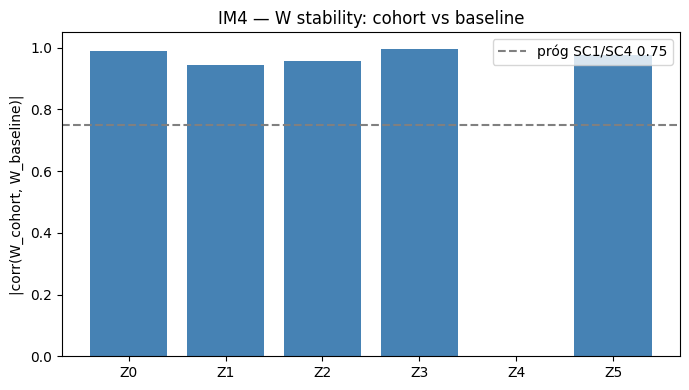

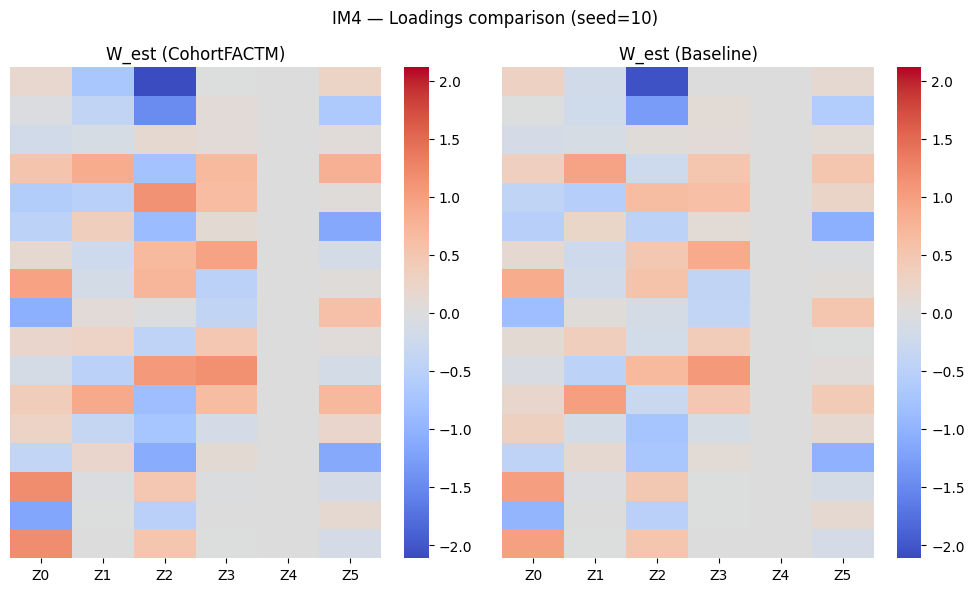

Pretraining CTM for structured view 0
Pretraining FA
Fitting model


100%|██████████| 150/150 [00:21<00:00,  7.12it/s]


Pretraining CTM for structured view 0
Pretraining FA
Fitting model


100%|██████████| 150/150 [00:21<00:00,  7.07it/s]


seed 10: mean|corr|=0.810
Pretraining CTM for structured view 0
Pretraining FA
Fitting model


...

seed 13: mean|corr|=0.753
Pretraining CTM for structured view 0
Pretraining FA
Fitting model


100%|██████████| 150/150 [00:19<00:00,  7.56it/s]


Pretraining CTM for structured view 0
Pretraining FA
Fitting model


100%|██████████| 150/150 [00:19<00:00,  7.54it/s]


seed 14: mean|corr|=0.819


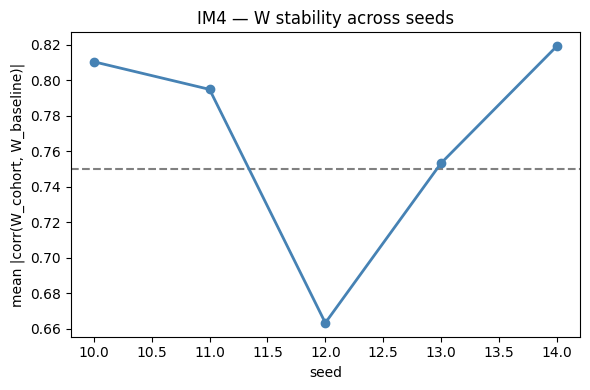

In [7]:
seed_im4 = 10
model_im4_c = fit_cohort(views, K, pi=PI, max_iter=MAX_ITER, seed=seed_im4)
model_im4_b = fit_baseline(views, K, max_iter=MAX_ITER, seed=seed_im4)

w_corrs_im4, perm_im4, signs_im4 = w_stability(model_im4_c, model_im4_b, K)
print(f"IM4 seed={seed_im4}: mean|corr(W)| = {w_corrs_im4[0].mean():.3f}")
print("Per factor:", w_corrs_im4[0].round(3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(K), w_corrs_im4[0], color='steelblue')
ax.axhline(0.75, color='gray', ls='--', label='próg SC1/SC4 0.75')
ax.set_xticks(range(K))
ax.set_xticklabels([f'Z{k}' for k in range(K)])
ax.set_ylabel('|corr(W_cohort, W_baseline)|')
ax.set_title('IM4 — W stability: cohort vs baseline')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

Wc = model_im4_c.fa.nodelist_w[0].E_w[:, perm_im4] * signs_im4[None, :]
Wb = model_im4_b.fa.nodelist_w[0].E_w
vmax = max(np.abs(Wc).max(), np.abs(Wb).max())

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
kw = dict(cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
          xticklabels=[f'Z{k}' for k in range(K)], yticklabels=False)
sns.heatmap(Wc, ax=axes[0], **kw)
axes[0].set_title('W_est (CohortFACTM)')
sns.heatmap(Wb, ax=axes[1], **kw)
axes[1].set_title('W_est (Baseline)')
plt.suptitle(f'IM4 — Loadings comparison (seed={seed_im4})')
plt.tight_layout()
plt.show()

# Multi-seed sweep (jak SC4 po mu0, tutaj po seed)
seeds_im4 = [10, 11, 12, 13, 14]
stab = []
for s in seeds_im4:
    mc = fit_cohort(views, K, pi=PI, max_iter=MAX_ITER, seed=s)
    mb = fit_baseline(views, K, max_iter=MAX_ITER, seed=s)
    wc, _, _ = w_stability(mc, mb, K)
    stab.append(wc[0].mean())
    print(f"seed {s}: mean|corr|={wc[0].mean():.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(seeds_im4, stab, yerr=0, marker='o', linewidth=2, color='steelblue')
ax.axhline(0.75, color='gray', ls='--')
ax.set_xlabel('seed')
ax.set_ylabel('mean |corr(W_cohort, W_baseline)|')
ax.set_title('IM4 — W stability across seeds')
plt.tight_layout()
plt.show()
